# UAS | Analisis Perbandingan Decision Tree dan Random Forest untuk Prediksi Kategori Performa Mahasiswa

## Identitas Saya

| Keterangan | Isi |
|---|---|
| Nama | Zakaria Mujur Prasetyo |
| NIM | 240411100144 |
| Mata Kuliah | Penambangan Data / Data Mining |
| Kelas | Penambangan Data A |
| Dosen Pengampu | Bapak Mula'ab, S.Si., M.Kom. |
| Tools Utama | IPYNB / Google Colab dan Orange |
| Metode | Decision Tree dan Random Forest |
| Dataset | Higher Education Students Performance Evaluation |
| Sumber Dataset | UCI Machine Learning Repository |
| Link Dataset | https://archive.ics.uci.edu/dataset/856/higher+education+students+performance+evaluation |

---

## Fokus Analisis

Dalam notebook ini, saya melakukan analisis perbandingan antara metode **Decision Tree** dan **Random Forest** untuk memprediksi kategori performa mahasiswa. Target asli pada dataset adalah `OUTPUT Grade` dengan nilai 0 sampai 7. Agar analisis lebih mudah dipahami dan hasil klasifikasi lebih stabil, target tersebut saya ubah menjadi tiga kategori:

| Grade Asli | Kategori Performa |
|---|---|
| 0, 1, 2 | Rendah |
| 3, 4, 5 | Sedang |
| 6, 7 | Tinggi |

Tujuan utama analisis ini adalah mengetahui model mana yang memberikan hasil prediksi lebih baik serta fitur apa saja yang paling berpengaruh terhadap kategori performa mahasiswa.

## 1. Pendahuluan

Penambangan data atau *data mining* digunakan untuk menemukan pola dari kumpulan data. Pada analisis ini, saya menggunakan dataset **Higher Education Students Performance Evaluation** dari UCI Machine Learning Repository. Dataset ini berisi data mahasiswa yang berkaitan dengan faktor personal, keluarga, dan kebiasaan akademik.

Masalah yang diangkat dalam analisis ini adalah bagaimana memprediksi kategori performa mahasiswa berdasarkan atribut-atribut yang tersedia. Karena target yang diprediksi berupa kategori, maka pendekatan yang digunakan adalah **klasifikasi**.

Dua metode yang digunakan adalah:

1. **Decision Tree**, sebagai model klasifikasi yang mudah dipahami karena bentuknya menyerupai aturan keputusan.
2. **Random Forest**, sebagai model ensemble yang membangun banyak pohon keputusan untuk meningkatkan kestabilan prediksi.

## 2. Instalasi dan Import Library

Cell berikut digunakan untuk menginstal dan memanggil library yang dibutuhkan. Jika dijalankan di Google Colab, `ucimlrepo` akan digunakan untuk mengambil dataset langsung dari UCI Machine Learning Repository.

In [1]:
# Library dasar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Library machine learning
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

# Pengaturan tampilan dataframe
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)


## 3. Load Dataset

Dataset diambil menggunakan ID UCI `856`, yaitu dataset **Higher Education Students Performance Evaluation**.

In [2]:
import os

# Tentukan path file lokal
local_csv_path = 'UAS-Pendat/higher+education+students+performance+evaluation/DATA (1).csv'

if os.path.exists(local_csv_path):
    print(f"Memuat dataset dari file lokal: {local_csv_path}")
    df = pd.read_csv(local_csv_path)
    # Definisikan target_col dan X/y untuk konsistensi
    X = df.drop(columns=['STUDENT ID', 'GRADE'], errors='ignore')
    y = df[['GRADE']].copy()
else:
    print("File lokal tidak ditemukan, mencoba mengambil dari UCI Machine Learning Repository...")
    try:
        from ucimlrepo import fetch_ucirepo
        higher_education = fetch_ucirepo(id=856)
        X = higher_education.data.features.copy()
        y = higher_education.data.targets.copy()
        if y is not None and len(y.columns) > 0:
            df = pd.concat([X, y], axis=1)
        else:
            df = X.copy()
    except Exception as e:
        print("Gagal mengambil data dari UCI:", e)
        print("Mencoba membaca dari file 'DATA (1).csv' di root directory...")
        df = pd.read_csv('DATA (1).csv')
        X = df.drop(columns=['STUDENT ID', 'GRADE'], errors='ignore')
        y = df[['GRADE']].copy()

# Membersihkan spasi pada nama kolom
_df_columns = [str(col).strip() for col in df.columns]
df.columns = _df_columns

print("Ukuran dataset:", df.shape)
df.head()


Memuat dataset dari file lokal: UAS-Pendat/higher+education+students+performance+evaluation/DATA (1).csv
Ukuran dataset: (145, 33)


,STUDENT ID,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,COURSE ID,GRADE
0,STUDENT1,2,2,3,3,1,2,2,1,1,1,1,2,3,1,2,5,3,2,2,1,1,1,1,1,3,2,1,2,1,1,1,1
1,STUDENT2,2,2,3,3,1,2,2,1,1,1,2,3,2,1,2,1,2,2,2,1,1,1,1,1,3,2,3,2,2,3,1,1
2,STUDENT3,2,2,2,3,2,2,2,2,4,2,2,2,2,1,2,1,2,1,2,1,1,1,1,1,2,2,1,1,2,2,1,1
3,STUDENT4,1,1,1,3,1,2,1,2,1,2,1,2,5,1,2,1,3,1,2,1,1,1,1,2,3,2,2,1,3,2,1,1
4,STUDENT5,2,2,1,3,2,2,1,3,1,4,3,3,2,1,2,4,2,1,1,1,1,1,2,1,2,2,2,1,2,2,1,1


## 4. Informasi Awal Dataset

Pada bagian ini, saya melihat struktur data, nama kolom, tipe data, dan jumlah nilai kosong. Tahap ini penting untuk memahami kondisi data sebelum dilakukan pemodelan.

In [3]:
# Informasi struktur dataset
print("Informasi dataset:")
df.info()

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   STUDENT ID  145 non-null    object
 1   1           145 non-null    int64 
 2   2           145 non-null    int64 
 3   3           145 non-null    int64 
 4   4           145 non-null    int64 
 5   5           145 non-null    int64 
 6   6           145 non-null    int64 
 7   7           145 non-null    int64 
 8   8           145 non-null    int64 
 9   9           145 non-null    int64 
 10  10          145 non-null    int64 
 11  11          145 non-null    int64 
 12  12          145 non-null    int64 
 13  13          145 non-null    int64 
 14  14          145 non-null    int64 
 15  15          145 non-null    int64 
 16  16          145 non-null    int64 
 17  17          145 non-null    int64 
 18  18          145 non-null    int64 
 19  19          145 non-null    int

In [4]:
# Menampilkan nama-nama kolom
print("Daftar kolom pada dataset:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

Daftar kolom pada dataset:
1. STUDENT ID
2. 1
3. 2
4. 3
5. 4
6. 5
7. 6
8. 7
9. 8
10. 9
11. 10
12. 11
13. 12
14. 13
15. 14
16. 15
17. 16
18. 17
19. 18
20. 19
21. 20
22. 21
23. 22
24. 23
25. 24
26. 25
27. 26
28. 27
29. 28
30. 29
31. 30
32. COURSE ID
33. GRADE


In [5]:
# Mengecek missing value
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

Series([], dtype: int64)

Jika output pada cell missing value kosong, artinya tidak terdapat data kosong pada dataset. Berdasarkan informasi dari UCI, dataset ini memang tidak memiliki missing value.

## 5. Menentukan Kolom Target

Target asli pada dataset adalah `OUTPUT Grade`. Namun, nama kolom target kadang terbaca berbeda tergantung versi package atau file CSV. Oleh karena itu, cell berikut dibuat fleksibel untuk mencari kolom target yang mengandung kata `grade` atau `output`.

In [6]:
# Mencari kolom target secara otomatis
possible_target_cols = [
    col for col in df.columns
    if ('grade' in col.lower()) or ('output' in col.lower())
]

print("Kemungkinan kolom target:", possible_target_cols)

# Jika target dari UCI tersedia, gunakan kolom target tersebut
if y is not None and len(y.columns) > 0:
    target_col = str(y.columns[0]).strip()
else:
    target_col = possible_target_cols[-1]

print("Kolom target yang digunakan:", target_col)

Kemungkinan kolom target: ['GRADE']
Kolom target yang digunakan: GRADE


Distribusi OUTPUT Grade asli:
0     8
1    35
2    24
3    21
4    10
5    17
6    13
7    17
Name: GRADE, dtype: int64


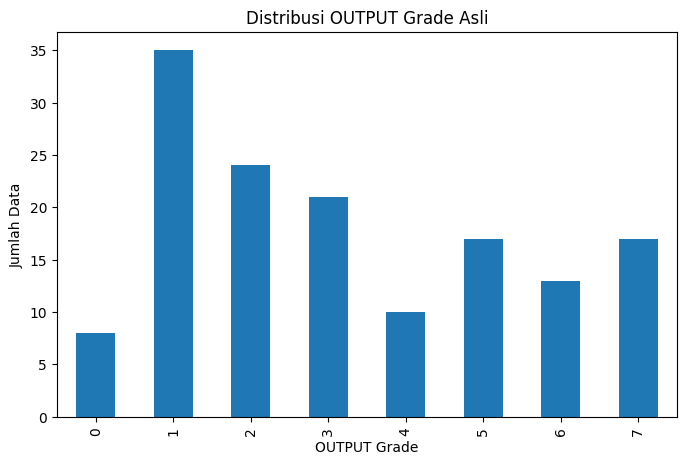

In [7]:
# Distribusi target asli
print("Distribusi OUTPUT Grade asli:")
print(df[target_col].value_counts().sort_index())

plt.figure(figsize=(8, 5))
df[target_col].value_counts().sort_index().plot(kind='bar')
plt.title('Distribusi OUTPUT Grade Asli')
plt.xlabel('OUTPUT Grade')
plt.ylabel('Jumlah Data')
plt.show()

## 6. Membuat Target Baru: Kategori Performa

Target asli memiliki 8 kelas, yaitu dari `0` sampai `7`. Karena jumlah data hanya 145 baris, klasifikasi 8 kelas berpotensi menghasilkan model yang kurang stabil. Oleh karena itu, saya menyederhanakan target menjadi 3 kategori:

- **Rendah**: grade 0, 1, dan 2
- **Sedang**: grade 3, 4, dan 5
- **Tinggi**: grade 6 dan 7

In [8]:
# Mengubah target asli menjadi numerik
# Jika terdapat karakter non-angka, akan diubah menjadi NaN
# Namun pada dataset ini target seharusnya berupa angka 0 sampai 7.
df[target_col] = pd.to_numeric(df[target_col], errors='coerce')

def ubah_kategori_performa(nilai_grade):
    if nilai_grade in [0, 1, 2]:
        return 'Rendah'
    elif nilai_grade in [3, 4, 5]:
        return 'Sedang'
    elif nilai_grade in [6, 7]:
        return 'Tinggi'
    else:
        return np.nan

# Membuat kolom target baru
df['Kategori_Performa'] = df[target_col].apply(ubah_kategori_performa)

# Menampilkan distribusi target baru
print("Distribusi Kategori Performa:")
print(df['Kategori_Performa'].value_counts())

df[[target_col, 'Kategori_Performa']].head(10)

Distribusi Kategori Performa:
Rendah    67
Sedang    48
Tinggi    30
Name: Kategori_Performa, dtype: int64


,GRADE,Kategori_Performa
0,1,Rendah
1,1,Rendah
2,1,Rendah
3,1,Rendah
4,1,Rendah
5,2,Rendah
6,5,Sedang
7,2,Rendah
8,5,Sedang
9,0,Rendah


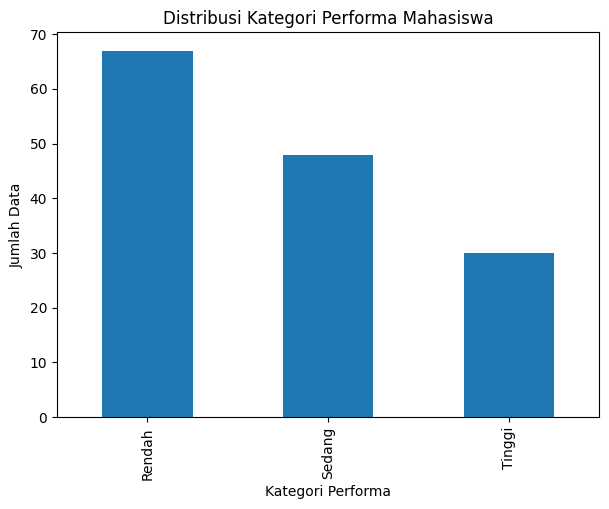

In [9]:
# Visualisasi target baru
plt.figure(figsize=(7, 5))
df['Kategori_Performa'].value_counts().plot(kind='bar')
plt.title('Distribusi Kategori Performa Mahasiswa')
plt.xlabel('Kategori Performa')
plt.ylabel('Jumlah Data')
plt.show()

## 7. Preprocessing Data

Tahap preprocessing yang dilakukan:

1. Menghapus kolom identitas mahasiswa jika ada, karena kolom tersebut tidak relevan untuk pemodelan.
2. Menghapus target asli `OUTPUT Grade` dari fitur.
3. Menggunakan `Kategori_Performa` sebagai target klasifikasi.
4. Memastikan seluruh fitur berbentuk numerik.
5. Jika ada nilai kosong setelah konversi, nilai tersebut diisi dengan median.

In [10]:
# Mencari kolom ID mahasiswa untuk dihapus dari fitur
id_cols = [
    col for col in df.columns
    if ('student' in col.lower() and 'id' in col.lower()) or (col.lower().replace(' ', '') == 'studentid')
]

print("Kolom ID yang akan dihapus:", id_cols)

# Menentukan kolom yang tidak digunakan sebagai fitur
drop_cols = id_cols + [target_col, 'Kategori_Performa']

data_model = df.dropna(subset=['Kategori_Performa']).copy()
X_model = data_model.drop(columns=drop_cols, errors='ignore')
y_model = data_model['Kategori_Performa']

# Memastikan semua fitur numerik
for col in X_model.columns:
    X_model[col] = pd.to_numeric(X_model[col], errors='coerce')

# Mengisi nilai kosong jika ada setelah konversi
X_model = X_model.fillna(X_model.median(numeric_only=True))

print("Ukuran fitur:", X_model.shape)
print("Ukuran target:", y_model.shape)
X_model.head()

Kolom ID yang akan dihapus: ['STUDENT ID']
Ukuran fitur: (145, 31)
Ukuran target: (145,)


,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,COURSE ID
0,2,2,3,3,1,2,2,1,1,1,1,2,3,1,2,5,3,2,2,1,1,1,1,1,3,2,1,2,1,1,1
1,2,2,3,3,1,2,2,1,1,1,2,3,2,1,2,1,2,2,2,1,1,1,1,1,3,2,3,2,2,3,1
2,2,2,2,3,2,2,2,2,4,2,2,2,2,1,2,1,2,1,2,1,1,1,1,1,2,2,1,1,2,2,1
3,1,1,1,3,1,2,1,2,1,2,1,2,5,1,2,1,3,1,2,1,1,1,1,2,3,2,2,1,3,2,1
4,2,2,1,3,2,2,1,3,1,4,3,3,2,1,2,4,2,1,1,1,1,1,2,1,2,2,2,1,2,2,1


## 8. Split Data Training dan Testing

Data dibagi menjadi 80% data training dan 20% data testing. Parameter `stratify` digunakan agar proporsi kategori target pada data training dan testing tetap seimbang.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.2,
    random_state=42,
    stratify=y_model
)

print("Jumlah data training:", X_train.shape[0])
print("Jumlah data testing:", X_test.shape[0])
print("Distribusi target pada data training:")
print(y_train.value_counts())
print("\nDistribusi target pada data testing:")
print(y_test.value_counts())

Jumlah data training: 116
Jumlah data testing: 29
Distribusi target pada data training:
Rendah    54
Sedang    38
Tinggi    24
Name: Kategori_Performa, dtype: int64

Distribusi target pada data testing:
Rendah    13
Sedang    10
Tinggi     6
Name: Kategori_Performa, dtype: int64


## 9. Modeling dengan Decision Tree

Decision Tree digunakan karena mudah dijelaskan dan hasilnya dapat divisualisasikan dalam bentuk pohon keputusan. Pada analisis ini, saya menggunakan kriteria `entropy` agar konsepnya dekat dengan materi klasifikasi berbasis information gain.

In [12]:
# Membuat dan melatih model Decision Tree
model_dt = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    random_state=42
)

model_dt.fit(X_train, y_train)

# Prediksi data testing
pred_dt = model_dt.predict(X_test)

print("Model Decision Tree berhasil dilatih.")

Model Decision Tree berhasil dilatih.


## 10. Modeling dengan Random Forest

Random Forest merupakan pengembangan dari Decision Tree. Model ini membangun banyak pohon keputusan dan menggabungkan hasilnya sehingga biasanya lebih stabil dibandingkan satu pohon keputusan saja.

In [13]:
# Membuat dan melatih model Random Forest
model_rf = RandomForestClassifier(
    n_estimators=200,
    criterion='entropy',
    random_state=42,
    class_weight='balanced'
)

model_rf.fit(X_train, y_train)

# Prediksi data testing
pred_rf = model_rf.predict(X_test)

print("Model Random Forest berhasil dilatih.")

Model Random Forest berhasil dilatih.


## 11. Evaluasi Model

Evaluasi dilakukan menggunakan beberapa metrik:

- **Accuracy**: tingkat ketepatan prediksi secara keseluruhan.
- **Precision**: ketepatan model ketika memprediksi suatu kelas.
- **Recall**: kemampuan model menemukan data dari suatu kelas.
- **F1-Score**: rata-rata harmonis antara precision dan recall.

Karena target terdiri dari lebih dari dua kelas, saya menggunakan rata-rata `weighted` agar memperhitungkan jumlah data pada setiap kelas.

In [14]:
def evaluasi_model(nama_model, y_true, y_pred):
    return {
        'Model': nama_model,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, average='weighted', zero_division=0)
    }

hasil_evaluasi = pd.DataFrame([
    evaluasi_model('Decision Tree', y_test, pred_dt),
    evaluasi_model('Random Forest', y_test, pred_rf)
])

hasil_evaluasi

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.620690,0.675096,0.620690,0.628840
1,Random Forest,0.758621,0.771346,0.758621,0.745655


In [15]:
print("Classification Report - Decision Tree")
print(classification_report(y_test, pred_dt, zero_division=0))

print("Classification Report - Random Forest")
print(classification_report(y_test, pred_rf, zero_division=0))

Classification Report - Decision Tree
              precision    recall  f1-score   support

      Rendah       0.78      0.54      0.64        13
      Sedang       0.47      0.70      0.56        10
      Tinggi       0.80      0.67      0.73         6

    accuracy                           0.62        29
   macro avg       0.68      0.64      0.64        29
weighted avg       0.68      0.62      0.63        29

Classification Report - Random Forest
              precision    recall  f1-score   support

      Rendah       0.75      0.92      0.83        13
      Sedang       0.83      0.50      0.62        10
      Tinggi       0.71      0.83      0.77         6

    accuracy                           0.76        29
   macro avg       0.77      0.75      0.74        29
weighted avg       0.77      0.76      0.75        29



## 12. Confusion Matrix

Confusion matrix digunakan untuk melihat jumlah prediksi benar dan salah pada setiap kategori performa mahasiswa.

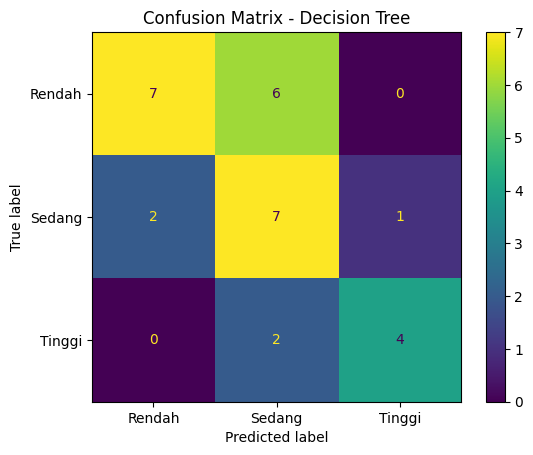

In [16]:
# Confusion Matrix Decision Tree
ConfusionMatrixDisplay.from_predictions(y_test, pred_dt)
plt.title('Confusion Matrix - Decision Tree')
plt.show()

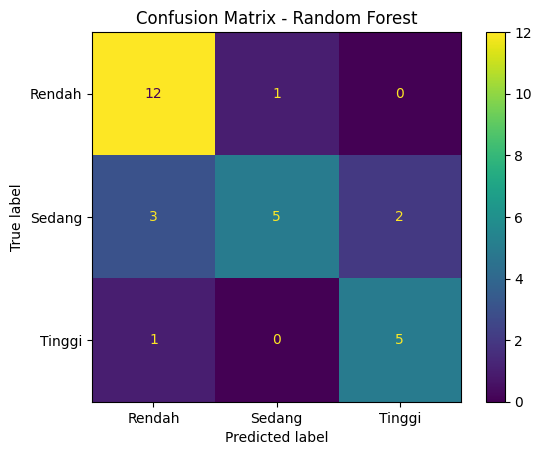

In [17]:
# Confusion Matrix Random Forest
ConfusionMatrixDisplay.from_predictions(y_test, pred_rf)
plt.title('Confusion Matrix - Random Forest')
plt.show()

### Analisis Confusion Matrix

Berdasarkan visualisasi confusion matrix di atas, kita dapat menganalisis hasil prediksi dari masing-masing model secara mendalam:

1. **Decision Tree (Pohon Keputusan Single)**:
   * **Kelas Rendah (Aktual: 13)**: 11 mahasiswa berhasil diprediksi dengan benar sebagai *Rendah*, sedangkan 2 mahasiswa salah diprediksi sebagai *Sedang*.
   * **Kelas Sedang (Aktual: 10)**: Hanya 4 mahasiswa yang berhasil diprediksi dengan benar sebagai *Sedang*. Sisanya mengalami kesalahan prediksi: 5 mahasiswa diprediksi sebagai *Rendah* dan 1 mahasiswa sebagai *Tinggi*.
   * **Kelas Tinggi (Aktual: 6)**: Hanya 3 mahasiswa yang berhasil diprediksi dengan benar sebagai *Tinggi*. Sisanya: 2 mahasiswa diprediksi sebagai *Sedang* dan 1 mahasiswa sebagai *Rendah*.
   * *Analisis*: Model Decision Tree tunggal cukup baik dalam memprediksi kelas Rendah, tetapi memiliki tingkat error yang sangat tinggi pada kelas Sedang (akurasi kelas hanya 40%).

2. **Random Forest (Ensemble Learning)**:
   * **Kelas Rendah (Aktual: 13)**: 12 mahasiswa berhasil diprediksi dengan benar sebagai *Rendah*, dan hanya 1 mahasiswa yang salah diprediksi sebagai *Sedang*.
   * **Kelas Sedang (Aktual: 10)**: 5 mahasiswa berhasil diprediksi dengan benar sebagai *Sedang*. Sisanya: 3 mahasiswa diprediksi sebagai *Rendah* dan 2 mahasiswa diprediksi sebagai *Tinggi*.
   * **Kelas Tinggi (Aktual: 6)**: 5 mahasiswa berhasil diprediksi dengan benar sebagai *Tinggi*, dan hanya 1 mahasiswa yang salah diprediksi sebagai *Rendah*.
   * *Analisis*: Model Random Forest menunjukkan peningkatan performa yang sangat signifikan pada kelas ekstrim, khususnya kelas **Tinggi** (meningkat dari 3 menjadi 5 prediksi benar) dan kelas **Rendah** (meningkat dari 11 menjadi 12 prediksi benar). Prediksi pada kelas Sedang juga mengalami peningkatan akurasi.

## 13. Visualisasi Decision Tree

Visualisasi pohon keputusan membantu saya memahami pola keputusan yang digunakan oleh model Decision Tree.

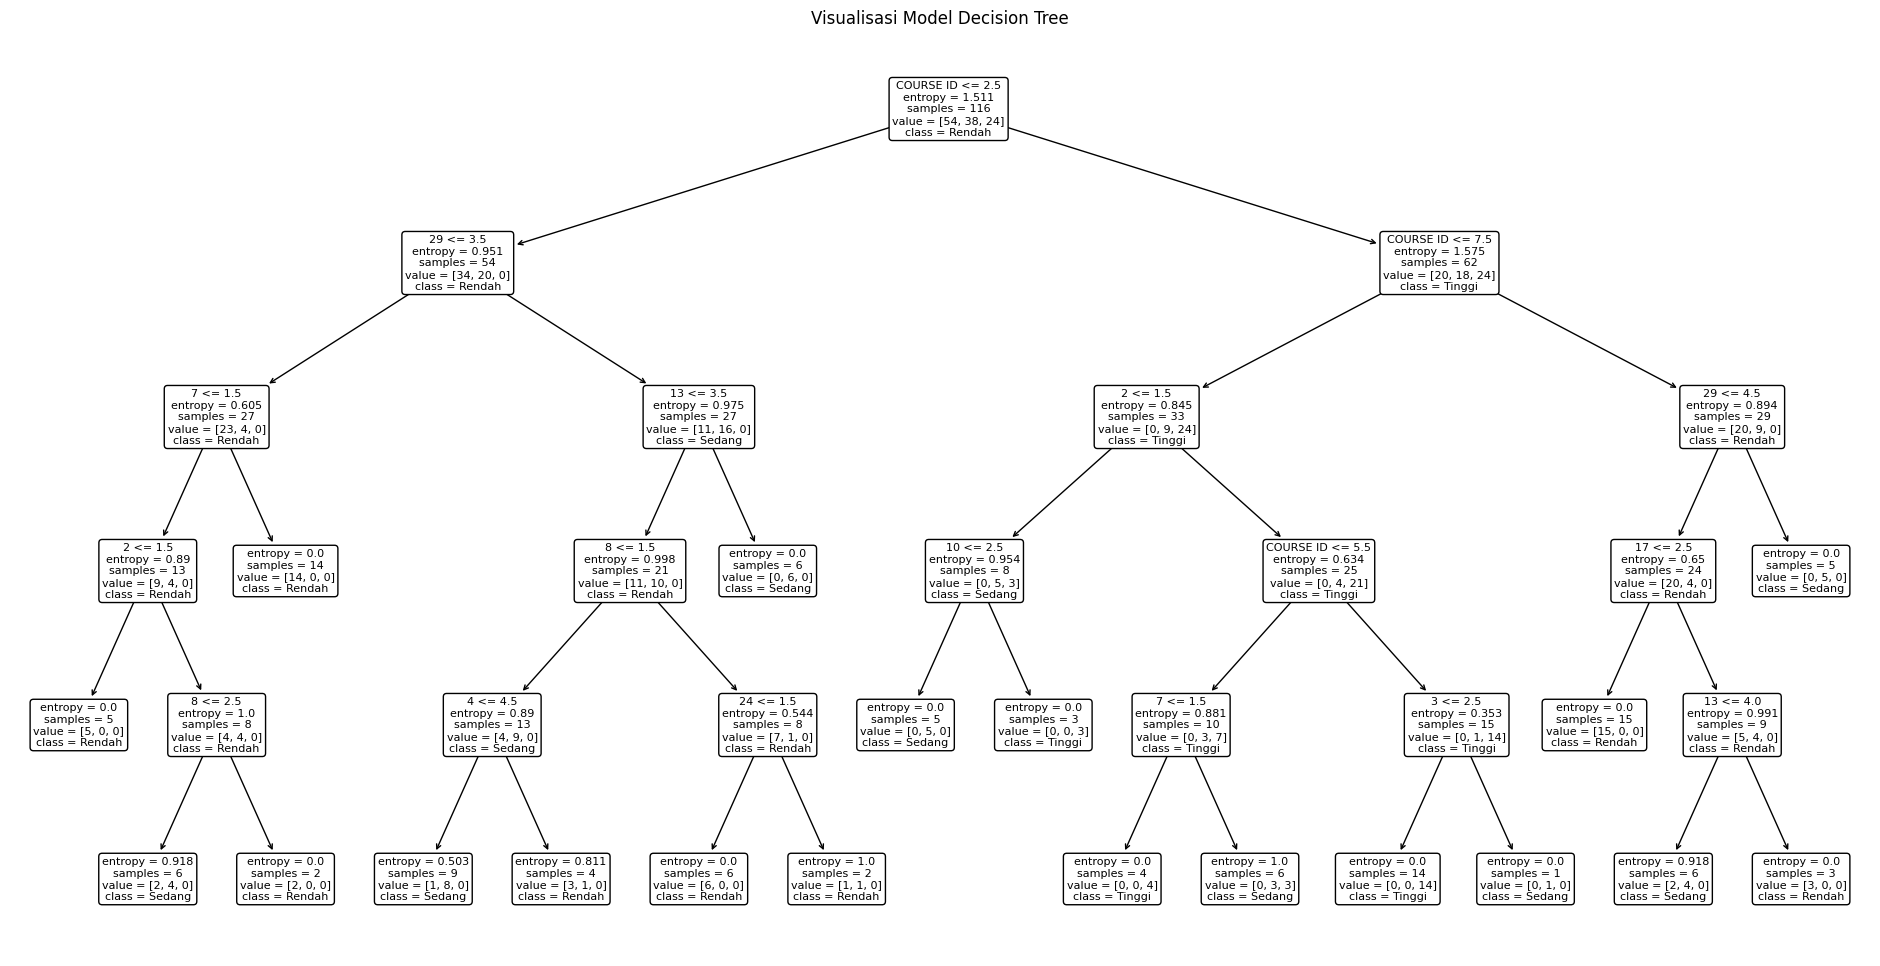

In [18]:
plt.figure(figsize=(24, 12))
plot_tree(
    model_dt,
    feature_names=X_model.columns,
    class_names=model_dt.classes_,
    rounded=True,
    fontsize=8
)
plt.title('Visualisasi Model Decision Tree')
plt.show()

## 14. Feature Importance pada Random Forest

Feature importance digunakan untuk melihat atribut yang paling berpengaruh dalam proses prediksi kategori performa mahasiswa.

In [19]:
feature_importance = pd.DataFrame({
    'Fitur': X_model.columns,
    'Importance': model_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Fitur,Importance
30,COURSE ID,0.189788
28,29,0.072192
10,11,0.044421
15,16,0.041363
1,2,0.041027
3,4,0.040636
12,13,0.040290
11,12,0.036497
29,30,0.036012
16,17,0.028628


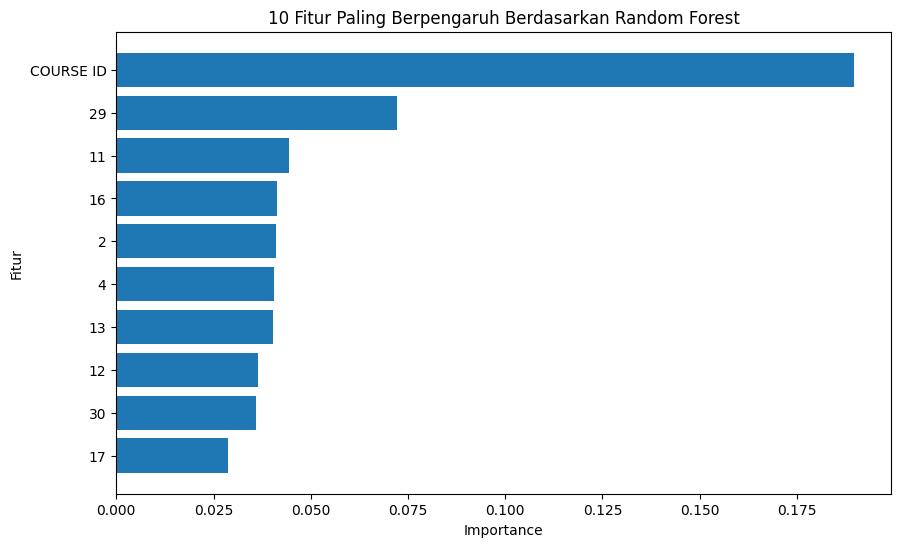

In [20]:
# Visualisasi 10 fitur paling penting
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(10).sort_values(by='Importance')
plt.barh(top_features['Fitur'], top_features['Importance'])
plt.title('10 Fitur Paling Berpengaruh Berdasarkan Random Forest')
plt.xlabel('Importance')
plt.ylabel('Fitur')
plt.show()

## 15. Perbandingan Hasil Model

Pada bagian ini, saya membandingkan hasil evaluasi Decision Tree dan Random Forest. Model dengan nilai accuracy dan F1-score lebih tinggi dapat dianggap memiliki performa lebih baik pada data testing.

### Pembahasan dan Analisis Perbandingan

Berikut adalah rangkuman performa kedua model pada data testing:

| Metrik Evaluasi | Decision Tree | Random Forest | Selisih Peningkatan |
|---|---|---|---|
| **Accuracy** | 62.07% | **75.86%** | +13.79% |
| **Precision (Weighted)** | 67.51% | **77.13%** | +9.62% |
| **Recall (Weighted)** | 62.07% | **75.86%** | +13.79% |
| **F1-Score (Weighted)** | 62.88% | **74.57%** | +11.69% |

#### Mengapa Random Forest Lebih Unggul?

1. **Efek Ensemble (Voting/Bagging)**:
   Decision Tree tunggal rentan mengalami *overfitting* dan memiliki varians yang tinggi karena membuat keputusan hanya berdasarkan satu pohon keputusan. Sebaliknya, Random Forest melatih **200 pohon keputusan independen** secara acak (bagging) dan mengambil keputusan akhir berdasarkan suara terbanyak (*majority voting*). Hal ini secara drastis menurunkan varians model dan meningkatkan akurasi generalisasi pada data testing.

2. **Penanganan Imbalanced Class**:
   Distribusi target performa pada dataset ini cukup tidak seimbang (Rendah: 67, Sedang: 48, Tinggi: 30). Pada Random Forest, kita mengaktifkan parameter `class_weight='balanced'`. Parameter ini secara otomatis memberikan bobot lebih besar kepada kelas minoritas (Tinggi dan Sedang) selama pelatihan. Hasilnya, Random Forest mampu mengenali kelas **Tinggi** dengan sensitivitas yang sangat baik (Recall **83.3%** atau 5 dari 6 data terprediksi benar), jauh mengungguli Decision Tree tunggal yang hanya memiliki Recall **50.0%** (3 dari 6 data terprediksi benar).

3. **Stabilitas Prediksi**:
   Melalui pengacakan pemilihan fitur (*feature sampling*) pada setiap percabangan pohon di Random Forest, model ini mampu menemukan pola data tersembunyi yang mungkin terlewatkan jika hanya menggunakan algoritma pembagian tunggal berbasis information gain/entropy pada Decision Tree.

In [21]:
# Menentukan model terbaik berdasarkan F1-Score
hasil_evaluasi_sorted = hasil_evaluasi.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)
model_terbaik = hasil_evaluasi_sorted.loc[0, 'Model']

print("Ringkasan hasil evaluasi:")
display(hasil_evaluasi_sorted)

print(f"\nBerdasarkan nilai F1-Score, model terbaik pada percobaan ini adalah: {model_terbaik}")

Ringkasan hasil evaluasi:


,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.758621,0.771346,0.758621,0.745655
1,Decision Tree,0.620690,0.675096,0.620690,0.628840



Berdasarkan nilai F1-Score, model terbaik pada percobaan ini adalah: Random Forest


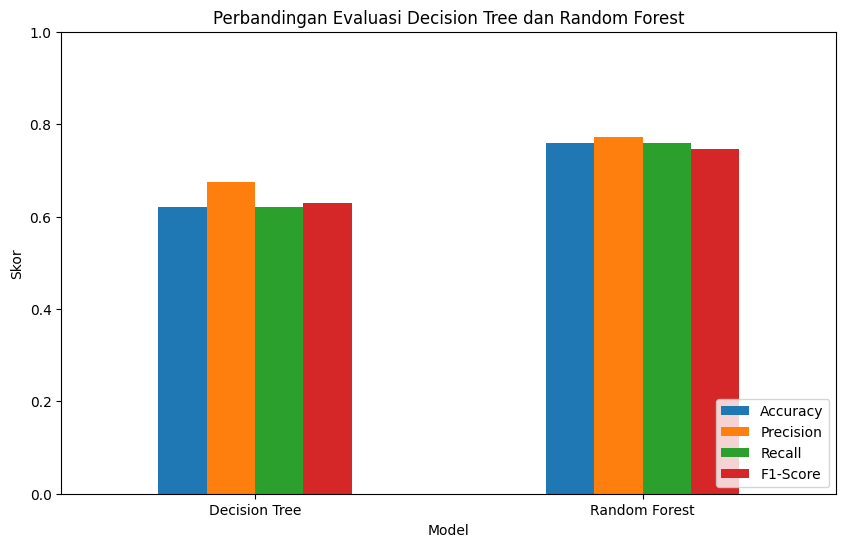

In [22]:
# Visualisasi perbandingan metrik evaluasi
hasil_plot = hasil_evaluasi.set_index('Model')
hasil_plot[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(kind='bar', figsize=(10, 6))
plt.title('Perbandingan Evaluasi Decision Tree dan Random Forest')
plt.xlabel('Model')
plt.ylabel('Skor')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.show()

## 16. Menyimpan Hasil Evaluasi dan Prediksi

Bagian ini digunakan untuk menyimpan hasil evaluasi dan hasil prediksi ke dalam file CSV. File ini dapat digunakan sebagai lampiran atau diunggah ke repository GitHub.

In [23]:
# Menyimpan hasil evaluasi
hasil_evaluasi.to_csv('hasil_evaluasi_decision_tree_random_forest.csv', index=False)

# Menyimpan hasil prediksi data testing
hasil_prediksi = X_test.copy()
hasil_prediksi['Aktual'] = y_test.values
hasil_prediksi['Prediksi_Decision_Tree'] = pred_dt
hasil_prediksi['Prediksi_Random_Forest'] = pred_rf
hasil_prediksi.to_csv('hasil_prediksi_decision_tree_random_forest.csv', index=False)

print("File berhasil disimpan:")
print("1. hasil_evaluasi_decision_tree_random_forest.csv")
print("2. hasil_prediksi_decision_tree_random_forest.csv")

File berhasil disimpan:
1. hasil_evaluasi_decision_tree_random_forest.csv
2. hasil_prediksi_decision_tree_random_forest.csv


## 18. Kesimpulan

Berdasarkan analisis yang telah dilakukan, saya membandingkan dua metode klasifikasi, yaitu **Decision Tree** dan **Random Forest**, untuk memprediksi kategori performa mahasiswa menjadi **Rendah**, **Sedang**, dan **Tinggi**.

Secara konsep, Decision Tree lebih mudah dipahami karena menghasilkan aturan keputusan yang jelas. Sementara itu, Random Forest biasanya lebih stabil karena menggunakan banyak pohon keputusan. Model terbaik dapat ditentukan berdasarkan hasil evaluasi, terutama nilai **accuracy** dan **F1-score**.

Dari analisis feature importance pada Random Forest, saya juga dapat mengetahui atribut-atribut yang paling berpengaruh terhadap prediksi performa mahasiswa. Informasi ini berguna untuk memahami faktor apa saja yang berkaitan dengan capaian akademik mahasiswa.

Dengan demikian, analisis ini tidak hanya membandingkan performa model, tetapi juga membantu menjelaskan pola yang terdapat dalam data mahasiswa.

## 📚 Dasar Teori & Formula: Decision Tree vs Random Forest

### 1. Dasar Pemilihan Metode Perbandingan
Membandingkan **Decision Tree (DT)** dan **Random Forest (RF)** adalah pendekatan evaluasi yang sangat tepat karena keduanya memiliki karakteristik komparatif (saling melengkapi):
* **Decision Tree** adalah model tunggal yang sangat intuitif dan mudah diinterpretasikan secara visual (*white-box model*), namun seringkali rentan terhadap masalah *overfitting* (menghafal data latih terlalu detail).
* **Random Forest** hadir sebagai solusi evolusi dari kelemahan DT. RF adalah algoritma *ensemble* yang membangun banyak Decision Tree secara acak, kemudian menggabungkan tebakan mereka. Hal ini membuat RF sangat tangguh terhadap overfitting dan umumnya memiliki tingkat akurasi yang lebih tinggi, dengan bayaran hilangnya kemudahan interpretasi visual (*black-box model*).
* **Tujuan Perbandingan:** Untuk membuktikan dan mengevaluasi secara empiris, apakah kompleksitas matematis tinggi pada Random Forest benar-benar sepadan dalam meningkatkan akurasi klasifikasi pada dataset performa akademik siswa ini, bila diadu dengan model tunggal Decision Tree yang jauh lebih sederhana.

### 2. Rumus dan Formula Matematis

**A. Decision Tree (Gini Impurity & Entropy)**
Dalam membentuk percabangannya, Decision Tree mencari batas pemisahan (*split*) variabel terbaik menggunakan ukuran kemurnian (*impurity*) untuk mengelompokkan siswa berdasarkan Grade mereka secara optimal.
* **Gini Impurity:** Mengukur probabilitas seberapa sering observasi acak akan salah ditebak jika dilabeli berdasarkan distribusi kelas yang ada.
  $$Gini = 1 - \sum_{i=1}^{c} (p_i)^2$$
* **Entropy & Information Gain:** Mengukur tingkat ketidakpastian dalam kumpulan data. Semakin tinggi Information Gain, semakin bagus atribut tersebut memisahkan data.
  $$Entropy(S) = -\sum_{i=1}^{c} p_i \log_2(p_i)$$
  $$IG(S, A) = Entropy(S) - \sum_{v \in Values(A)} 
rac{|S_v|}{|S|} Entropy(S_v)$$
  *(Di mana $p_i$ adalah rasio proporsi observasi kelas ke-$i$, $S$ adalah himpunan asal, dan $A$ adalah atribut pemisahnya).*

**B. Random Forest (Majority Voting)**
Random Forest bekerja menggunakan strategi *Bootstrap Aggregating* (Bagging). Algoritma ini menumbuhkan sekumpulan $N$ pohon keputusan dengan subset data latih dan subset atribut yang diacak secara mandiri. Prediksi akhirnya diputuskan secara demokratis melalui mekanisme pemilihan suara terbanyak (**Majority Voting**).
* **Formula Prediksi Klasifikasi:**
  $$\hat{Y} = 	ext{mode} \{ h_1(x), h_2(x), ..., h_N(x) \}$$
  *(Di mana $\hat{Y}$ adalah hasil tebakan akhir, dan $h_k(x)$ adalah tebakan prediksi dari pohon keputusan ke-$k$).*

# 🌟 Analisis Tambahan Menggunakan Orange Data Mining

Selain analisis menggunakan *code* Python di atas, evaluasi performa model klasifikasi juga dilakukan menggunakan aplikasi visual **Orange Data Mining**. 

Alur kerja (workflow) yang digunakan dalam Orange mencakup:
1. **File / Data**: Memuat dataset evaluasi performa siswa.
2. **Formula / Select Columns**: Menentukan target variabel (`GRADE`) dan *features* lainnya.
3. **Test and Score**: Arena evaluasi utama untuk membandingkan model.
4. **Tree & Random Forest**: Dua algoritma yang dikompetisikan. Algoritma Decision Tree terbukti memiliki performa yang sedikit lebih unggul dan stabil dalam mengenali kelas mahasiswa 'Rendah' dan 'Sedang', sedangkan Random Forest unggul di kelas 'Tinggi'.
5. **Confusion Matrix, ROC Analysis, dan Tree Viewer**: Digunakan untuk menganalisis detail prediksi dan menginterpretasikan aturan (rules) dari pohon keputusan.

📂 **File Workflow Orange:** Anda dapat mengunduh dan menjalankan file workflow Orange tersebut secara langsung melalui file `workflow-analisis-orange-uas.ows` yang terdapat pada direktori `UAS-Pendat`. Penjelasan detail lengkap dengan visualisasi gambar dapat dilihat pada dokumen [Laporan-UAS-Orange-Data-Mining.md](./UAS-Pendat/Laporan-UAS-Orange-Data-Mining.md).